# Acceleration du gradient et du sous-gradient

## Objectif TP3

Le but est de repartir du cadre experimental deja fige dans le projet et de comparer plusieurs methodes d'optimisation:

- `Gradient standard`;
- `Momentum`;
- `Nesterov`;
- `AdaGrad`;
- `RMSProp`;
- `Adam`.

Pour la regression, on regarde surtout la baisse de la perte et du `RMSE`.
Pour la classification binaire, on regarde la perte hinge, l'accuracy et le `F1`.


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch import nn, optim


from data_loader import create_dataloaders, resolve_default_paths
from experiment_spec import EXPERIMENTAL_FRAME
from train_common import (
    BinaryHingeLoss,
    build_model,
    evaluate_classification,
    evaluate_regression,
    select_device,
    set_seed,
    train_one_epoch,
)


In [2]:
defaults = resolve_default_paths()
device = select_device('auto')

OPTIMIZERS = [
    'sgd',
    'momentum',
    'nesterov',
    'adagrad',
    'rmsprop',
    'adam',
]

MODEL_NAMES = ['simple', 'improved']

BASE_CONFIG = {
    'image_dir': defaults['image_dir'],
    'attr_file': defaults['attr_file'],
    'partition_file': defaults['partition_file'],
    'batch_size': 32,
    'image_size': 64,
    'num_workers': 0,
    'seed': 42,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    'augment': False,
}

REGRESSION_LR = {
    'sgd': 1e-2,
    'momentum': 1e-2,
    'nesterov': 1e-2,
    'adagrad': 5e-3,
    'rmsprop': 1e-3,
    'adam': 1e-3,
}

CLASSIFICATION_LR = {
    'sgd': 1e-2,
    'momentum': 1e-2,
    'nesterov': 1e-2,
    'adagrad': 5e-3,
    'rmsprop': 1e-3,
    'adam': 1e-3,
}

EPOCHS_REGRESSION = 5
EPOCHS_CLASSIFICATION = 5

for key in ['image_dir', 'attr_file']:
    print(key, '->', BASE_CONFIG[key], Path(BASE_CONFIG[key]).exists())
print('device ->', device)
print('experimental frame ->', EXPERIMENTAL_FRAME)


image_dir -> data/img_align_celeba_reduced True
attr_file -> data/list_attr_celeba.csv True
device -> cpu
experimental frame -> {'dataset': {'name': 'CelebA reduced', 'type': 'image attributes', 'note': 'Use the reduced CelebA split when available, otherwise fall back to CelebA.'}, 'models': {'CNN1': 'simple', 'CNN2': 'improved'}, 'regression': {'name': 'attribute_sum_regression', 'description': 'Predict the sum of all available CelebA attributes.', 'target_column_mode': 'all_attributes_sum', 'loss': 'mse', 'selection_metric': 'rmse'}, 'classification': {'name': 'smiling_binary_classification', 'description': 'Predict whether the face is smiling from a raw scalar score.', 'target_column': 'Smiling', 'label_scheme': 'signed', 'labels': [-1, 1], 'decision_rule': 'sign(score)', 'loss': 'hinge', 'selection_metric': 'f1'}}


## Fonctions utilitaires

Les fonctions ci-dessous standardisent les experiences pour que la seule difference vienne bien de l'optimiseur. Cela permet une comparaison plus juste entre les methodes et entre `CNN1` et `CNN2`.


In [3]:
def make_optimizer(name, parameters, lr, weight_decay=1e-4):
    if name == 'sgd':
        return optim.SGD(parameters, lr=lr, weight_decay=weight_decay)
    if name == 'momentum':
        return optim.SGD(parameters, lr=lr, momentum=0.9, weight_decay=weight_decay)
    if name == 'nesterov':
        return optim.SGD(parameters, lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    if name == 'adagrad':
        return optim.Adagrad(parameters, lr=lr, weight_decay=weight_decay)
    if name == 'rmsprop':
        return optim.RMSprop(parameters, lr=lr, weight_decay=weight_decay)
    if name == 'adam':
        return optim.Adam(parameters, lr=lr, weight_decay=weight_decay)
    raise ValueError(f'Unknown optimizer: {name}')


def select_metric(task):
    if task == 'regression':
        return 'rmse', 'min'
    return 'f1', 'max'


def find_best_epoch(history, task):
    metric_name, mode = select_metric(task)
    values = [row[f'val_{metric_name}'] for row in history]
    if mode == 'min':
        idx = int(np.argmin(values))
    else:
        idx = int(np.argmax(values))
    return idx + 1, float(values[idx])


def compute_stability(history, task):
    metric_name, _ = select_metric(task)
    values = np.asarray([row[f'val_{metric_name}'] for row in history], dtype=float)
    if len(values) < 2:
        return 0.0
    deltas = np.diff(values)
    return float(np.std(deltas))


def get_loaders(task):
    common_kwargs = dict(
        img_dir=BASE_CONFIG['image_dir'],
        attr_file=BASE_CONFIG['attr_file'],
        partition_file=BASE_CONFIG['partition_file'] if Path(BASE_CONFIG['partition_file']).exists() else None,
        batch_size=BASE_CONFIG['batch_size'],
        image_size=BASE_CONFIG['image_size'],
        num_workers=BASE_CONFIG['num_workers'],
        seed=BASE_CONFIG['seed'],
        val_ratio=BASE_CONFIG['val_ratio'],
        test_ratio=BASE_CONFIG['test_ratio'],
        augment=BASE_CONFIG['augment'],
    )
    if task == 'regression':
        return create_dataloaders(target_type='regression', **common_kwargs)
    return create_dataloaders(
        target_type='classification',
        target_column=EXPERIMENTAL_FRAME['classification']['target_column'],
        classification_label_scheme=EXPERIMENTAL_FRAME['classification']['label_scheme'],
        **common_kwargs,
    )


def run_optimizer_experiment(task, model_name, optimizer_name, epochs, lr, weight_decay=1e-4):
    set_seed(BASE_CONFIG['seed'])
    loaders, dataset_sizes = get_loaders(task)
    model = build_model(model_name, task=task).to(device)

    if task == 'regression':
        criterion = nn.MSELoss()
        evaluator = evaluate_regression
    else:
        criterion = BinaryHingeLoss()
        evaluator = evaluate_classification

    optimizer = make_optimizer(optimizer_name, model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, loaders['train'], criterion, optimizer, device)
        train_metrics = evaluator(model, loaders['train'], criterion, device)
        val_metrics = evaluator(model, loaders['val'], criterion, device)

        row = {
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_metrics['loss'],
        }

        if task == 'regression':
            row.update({
                'train_mae': train_metrics['mae'],
                'train_rmse': train_metrics['rmse'],
                'val_mae': val_metrics['mae'],
                'val_rmse': val_metrics['rmse'],
                'val_r2': val_metrics['r2'],
            })
        else:
            row.update({
                'train_accuracy': train_metrics['accuracy'],
                'train_f1': train_metrics['f1'],
                'val_accuracy': val_metrics['accuracy'],
                'val_precision': val_metrics['precision'],
                'val_recall': val_metrics['recall'],
                'val_f1': val_metrics['f1'],
            })

        history.append(row)

    elapsed = time.perf_counter() - start
    test_metrics = evaluator(model, loaders['test'], criterion, device)
    best_epoch, best_val_metric = find_best_epoch(history, task)
    stability = compute_stability(history, task)

    summary = {
        'task': task,
        'model': model_name,
        'optimizer': optimizer_name,
        'lr': lr,
        'weight_decay': weight_decay,
        'epochs': epochs,
        'dataset_sizes': dataset_sizes,
        'history': history,
        'test_metrics': test_metrics,
        'best_epoch': best_epoch,
        'best_val_metric': best_val_metric,
        'stability': stability,
        'elapsed_seconds': elapsed,
    }
    return summary


def summarize_results(results, task):
    rows = []
    for item in results:
        row = {
            'model': item['model'],
            'optimizer': item['optimizer'],
            'lr': item['lr'],
            'best_epoch': item['best_epoch'],
            'best_val_metric': item['best_val_metric'],
            'stability': item['stability'],
            'elapsed_seconds': item['elapsed_seconds'],
            'test_loss': item['test_metrics']['loss'],
        }
        if task == 'regression':
            row.update({
                'test_mae': item['test_metrics']['mae'],
                'test_rmse': item['test_metrics']['rmse'],
                'test_r2': item['test_metrics']['r2'],
            })
        else:
            row.update({
                'test_accuracy': item['test_metrics']['accuracy'],
                'test_precision': item['test_metrics']['precision'],
                'test_recall': item['test_metrics']['recall'],
                'test_f1': item['test_metrics']['f1'],
            })
        rows.append(row)
    return pd.DataFrame(rows)


def run_sensitivity_study(task, model_name, optimizer_names, learning_rates, epochs):
    rows = []
    for optimizer_name in optimizer_names:
        for lr in learning_rates:
            result = run_optimizer_experiment(task, model_name, optimizer_name, epochs=epochs, lr=lr)
            rows.append({
                'task': task,
                'model': model_name,
                'optimizer': optimizer_name,
                'lr': lr,
                'best_epoch': result['best_epoch'],
                'best_val_metric': result['best_val_metric'],
                'stability': result['stability'],
            })
    return pd.DataFrame(rows)


## Accelerateurs pour le gradient en regression

La cellule suivante entraine `CNN1` puis `CNN2` sur la regression pour chacun des six optimiseurs demandes. On compare ensuite vitesse de convergence, `RMSE`, `R^2` et stabilite.


In [4]:
regression_results = []

for model_name in MODEL_NAMES:
    for optimizer_name in OPTIMIZERS:
        print(f'[regression] model={model_name} optimizer={optimizer_name}')
        result = run_optimizer_experiment(
            task='regression',
            model_name=model_name,
            optimizer_name=optimizer_name,
            epochs=EPOCHS_REGRESSION,
            lr=REGRESSION_LR[optimizer_name],
        )
        regression_results.append(result)

regression_summary = summarize_results(regression_results, task='regression')
regression_summary.sort_values(['model', 'test_rmse']).reset_index(drop=True)


[regression] model=simple optimizer=sgd
[regression] model=simple optimizer=momentum
[regression] model=simple optimizer=nesterov
[regression] model=simple optimizer=adagrad
[regression] model=simple optimizer=rmsprop
[regression] model=simple optimizer=adam
[regression] model=improved optimizer=sgd
[regression] model=improved optimizer=momentum
[regression] model=improved optimizer=nesterov
[regression] model=improved optimizer=adagrad
[regression] model=improved optimizer=rmsprop
[regression] model=improved optimizer=adam


,model,optimizer,lr,best_epoch,best_val_metric,stability,elapsed_seconds,test_loss,test_mae,test_rmse,test_r2
0,improved,adam,0.001,4,4.055650,0.495869,505.991479,16.750644,3.286358,4.092755,0.486781
1,improved,rmsprop,0.001,5,4.970104,0.378407,554.330441,23.684012,3.915077,4.866622,0.274351
2,improved,adagrad,0.005,4,5.040377,0.214154,566.610131,28.534484,4.302969,5.341768,0.125739
3,improved,sgd,0.010,1,NaN,NaN,439.384717,NaN,NaN,NaN,NaN
4,improved,momentum,0.010,1,NaN,NaN,434.063324,NaN,NaN,NaN,NaN
5,improved,nesterov,0.010,1,NaN,NaN,532.560294,NaN,NaN,NaN,NaN
6,simple,adam,0.001,5,4.326516,0.443465,253.773475,18.095865,3.446426,4.253924,0.445565
7,simple,rmsprop,0.001,5,4.416220,0.206101,304.777780,20.029237,3.590572,4.475403,0.386329
8,simple,adagrad,0.005,5,5.088932,0.026252,455.536576,27.096397,4.202791,5.205420,0.169800
9,simple,momentum,0.010,1,5.830988,0.020147,415.498727,32.640756,4.670992,5.713209,-0.000072


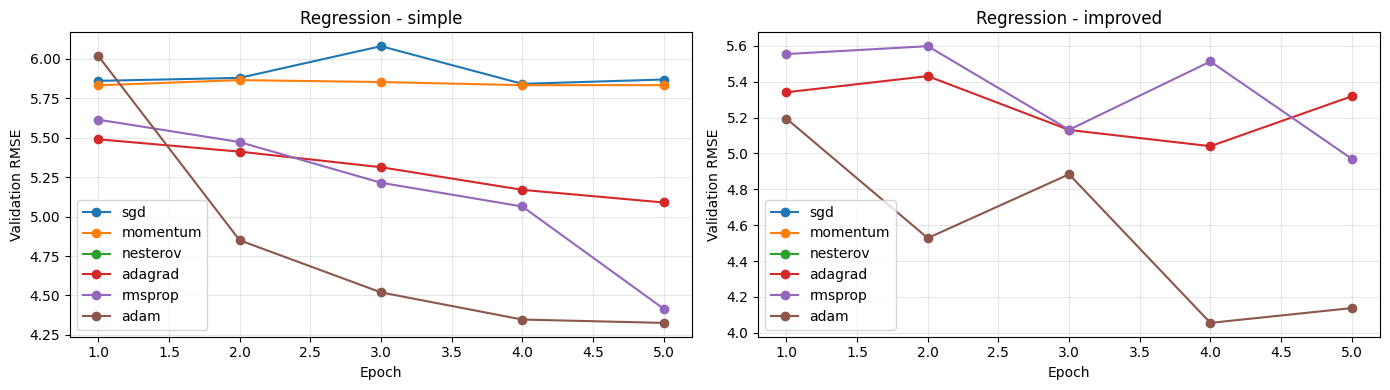

In [5]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(14, 4), sharey=False)

for ax, model_name in zip(axes, MODEL_NAMES):
    for item in regression_results:
        if item['model'] != model_name:
            continue
        epochs = [row['epoch'] for row in item['history']]
        values = [row['val_rmse'] for row in item['history']]
        ax.plot(epochs, values, marker='o', label=item['optimizer'])
    ax.set_title(f'Regression - {model_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation RMSE')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()


##  Accelerateurs pour le sous-gradient en classification

Ici, on garde la formulation du TP2:

- score brut `s_theta(x)`;
- prediction par `sign(s_theta(x))`;
- perte hinge non differentiable.

Le but du TP3 est de voir si les techniques d'acceleration ameliorent la convergence du sous-gradient dans ce cadre.


In [6]:
classification_results = []

for model_name in MODEL_NAMES:
    for optimizer_name in OPTIMIZERS:
        print(f'[classification] model={model_name} optimizer={optimizer_name}')
        result = run_optimizer_experiment(
            task='classification',
            model_name=model_name,
            optimizer_name=optimizer_name,
            epochs=EPOCHS_CLASSIFICATION,
            lr=CLASSIFICATION_LR[optimizer_name],
        )
        classification_results.append(result)

classification_summary = summarize_results(classification_results, task='classification')
classification_summary.sort_values(['model', 'test_f1'], ascending=[True, False]).reset_index(drop=True)


[classification] model=simple optimizer=sgd
[classification] model=simple optimizer=momentum
[classification] model=simple optimizer=nesterov
[classification] model=simple optimizer=adagrad
[classification] model=simple optimizer=rmsprop
[classification] model=simple optimizer=adam
[classification] model=improved optimizer=sgd
[classification] model=improved optimizer=momentum
[classification] model=improved optimizer=nesterov
[classification] model=improved optimizer=adagrad
[classification] model=improved optimizer=rmsprop
[classification] model=improved optimizer=adam


,model,optimizer,lr,best_epoch,best_val_metric,stability,elapsed_seconds,test_loss,test_accuracy,test_precision,test_recall,test_f1
0,improved,sgd,0.010,5,0.912863,0.023196,556.165561,0.228237,0.911,0.908894,0.899142,0.903991
1,improved,adagrad,0.005,5,0.922092,0.014555,504.115738,0.219250,0.906,0.909692,0.886266,0.897826
2,improved,nesterov,0.010,4,0.917471,0.014782,611.680847,0.222654,0.904,0.928241,0.860515,0.893096
3,improved,adam,0.001,5,0.919614,0.009278,313.541294,0.224982,0.899,0.906459,0.873391,0.889617
4,improved,rmsprop,0.001,4,0.898288,0.031481,630.464810,0.247386,0.899,0.931442,0.845494,0.886389
5,improved,momentum,0.010,3,0.923077,0.021781,616.743257,0.229540,0.896,0.933014,0.836910,0.882353
6,simple,nesterov,0.010,5,0.886128,0.013832,253.889003,0.247360,0.902,0.891489,0.899142,0.895299
7,simple,rmsprop,0.001,5,0.897917,0.016961,369.870908,0.245204,0.897,0.897155,0.879828,0.888407
8,simple,momentum,0.010,5,0.901919,0.020260,249.248805,0.266161,0.896,0.913242,0.858369,0.884956
9,simple,adam,0.001,4,0.896851,0.011576,293.628356,0.267533,0.895,0.952381,0.815451,0.878613


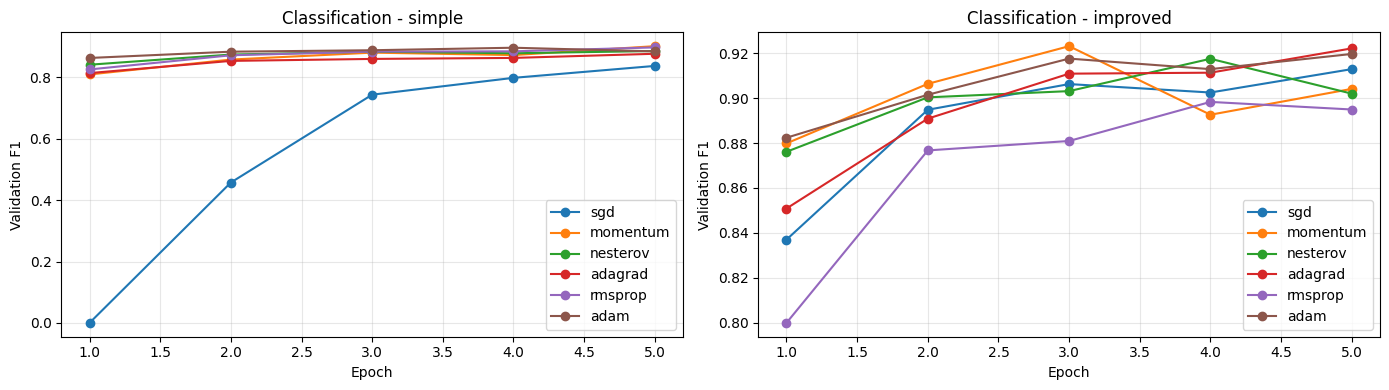

In [7]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(14, 4), sharey=False)

for ax, model_name in zip(axes, MODEL_NAMES):
    for item in classification_results:
        if item['model'] != model_name:
            continue
        epochs = [row['epoch'] for row in item['history']]
        values = [row['val_f1'] for row in item['history']]
        ax.plot(epochs, values, marker='o', label=item['optimizer'])
    ax.set_title(f'Classification - {model_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation F1')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()


## Comparaison globale

On compare:

- la vitesse de convergence;
- la stabilite;
- le cout final;
- la qualite finale;
- la sensibilite aux hyperparametres;
- les differences entre `CNN1` et `CNN2`.


In [8]:
print('Regression summary')
display(regression_summary.sort_values(['model', 'test_rmse']).reset_index(drop=True))

print('Classification summary')
display(classification_summary.sort_values(['model', 'test_f1'], ascending=[True, False]).reset_index(drop=True))

regression_best_by_model = regression_summary.sort_values('test_rmse').groupby('model', as_index=False).first()
classification_best_by_model = classification_summary.sort_values('test_f1', ascending=False).groupby('model', as_index=False).first()

print('Best regression optimizer per model')
display(regression_best_by_model)

print('Best classification optimizer per model')
display(classification_best_by_model)


Regression summary


,model,optimizer,lr,best_epoch,best_val_metric,stability,elapsed_seconds,test_loss,test_mae,test_rmse,test_r2
0,improved,adam,0.001,4,4.055650,0.495869,505.991479,16.750644,3.286358,4.092755,0.486781
1,improved,rmsprop,0.001,5,4.970104,0.378407,554.330441,23.684012,3.915077,4.866622,0.274351
2,improved,adagrad,0.005,4,5.040377,0.214154,566.610131,28.534484,4.302969,5.341768,0.125739
3,improved,sgd,0.010,1,NaN,NaN,439.384717,NaN,NaN,NaN,NaN
4,improved,momentum,0.010,1,NaN,NaN,434.063324,NaN,NaN,NaN,NaN
5,improved,nesterov,0.010,1,NaN,NaN,532.560294,NaN,NaN,NaN,NaN
6,simple,adam,0.001,5,4.326516,0.443465,253.773475,18.095865,3.446426,4.253924,0.445565
7,simple,rmsprop,0.001,5,4.416220,0.206101,304.777780,20.029237,3.590572,4.475403,0.386329
8,simple,adagrad,0.005,5,5.088932,0.026252,455.536576,27.096397,4.202791,5.205420,0.169800
9,simple,momentum,0.010,1,5.830988,0.020147,415.498727,32.640756,4.670992,5.713209,-0.000072


Classification summary


,model,optimizer,lr,best_epoch,best_val_metric,stability,elapsed_seconds,test_loss,test_accuracy,test_precision,test_recall,test_f1
0,improved,sgd,0.010,5,0.912863,0.023196,556.165561,0.228237,0.911,0.908894,0.899142,0.903991
1,improved,adagrad,0.005,5,0.922092,0.014555,504.115738,0.219250,0.906,0.909692,0.886266,0.897826
2,improved,nesterov,0.010,4,0.917471,0.014782,611.680847,0.222654,0.904,0.928241,0.860515,0.893096
3,improved,adam,0.001,5,0.919614,0.009278,313.541294,0.224982,0.899,0.906459,0.873391,0.889617
4,improved,rmsprop,0.001,4,0.898288,0.031481,630.464810,0.247386,0.899,0.931442,0.845494,0.886389
5,improved,momentum,0.010,3,0.923077,0.021781,616.743257,0.229540,0.896,0.933014,0.836910,0.882353
6,simple,nesterov,0.010,5,0.886128,0.013832,253.889003,0.247360,0.902,0.891489,0.899142,0.895299
7,simple,rmsprop,0.001,5,0.897917,0.016961,369.870908,0.245204,0.897,0.897155,0.879828,0.888407
8,simple,momentum,0.010,5,0.901919,0.020260,249.248805,0.266161,0.896,0.913242,0.858369,0.884956
9,simple,adam,0.001,4,0.896851,0.011576,293.628356,0.267533,0.895,0.952381,0.815451,0.878613


Best regression optimizer per model


,model,optimizer,lr,best_epoch,best_val_metric,stability,elapsed_seconds,test_loss,test_mae,test_rmse,test_r2
0,improved,adam,0.001,4,4.055650,0.495869,505.991479,16.750644,3.286358,4.092755,0.486781
1,simple,adam,0.001,5,4.326516,0.443465,253.773475,18.095865,3.446426,4.253924,0.445565


Best classification optimizer per model


,model,optimizer,lr,best_epoch,best_val_metric,stability,elapsed_seconds,test_loss,test_accuracy,test_precision,test_recall,test_f1
0,improved,sgd,0.01,5,0.912863,0.023196,556.165561,0.228237,0.911,0.908894,0.899142,0.903991
1,simple,nesterov,0.01,5,0.886128,0.013832,253.889003,0.247360,0.902,0.891489,0.899142,0.895299


In [9]:
sensitivity_lrs = [3e-4, 1e-3, 3e-3]
optimizers_for_sensitivity = ['sgd', 'momentum', 'adam']

regression_sensitivity = run_sensitivity_study(
    task='regression',
    model_name='improved',
    optimizer_names=optimizers_for_sensitivity,
    learning_rates=sensitivity_lrs,
    epochs=3,
)

classification_sensitivity = run_sensitivity_study(
    task='classification',
    model_name='improved',
    optimizer_names=optimizers_for_sensitivity,
    learning_rates=sensitivity_lrs,
    epochs=3,
)

print('Sensitivity study - regression (CNN2)')
display(regression_sensitivity.sort_values(['optimizer', 'lr']))

print('Sensitivity study - classification (CNN2)')
display(classification_sensitivity.sort_values(['optimizer', 'lr']))


Sensitivity study - regression (CNN2)


,task,model,optimizer,lr,best_epoch,best_val_metric,stability
6,regression,improved,adam,0.0003,2,4.350962,0.701347
7,regression,improved,adam,0.0010,2,4.528248,0.510641
8,regression,improved,adam,0.0030,3,4.708560,0.303636
3,regression,improved,momentum,0.0003,3,5.326389,0.037986
4,regression,improved,momentum,0.0010,1,5.831446,0.001072
5,regression,improved,momentum,0.0030,1,NaN,NaN
0,regression,improved,sgd,0.0003,2,5.160350,1.920885
1,regression,improved,sgd,0.0010,2,6.006749,0.817347
2,regression,improved,sgd,0.0030,3,5.835804,0.178295


Sensitivity study - classification (CNN2)


,task,model,optimizer,lr,best_epoch,best_val_metric,stability
6,classification,improved,adam,0.0003,2,0.916923,0.009153
7,classification,improved,adam,0.0010,3,0.917548,0.001517
8,classification,improved,adam,0.0030,3,0.875406,0.164445
3,classification,improved,momentum,0.0003,3,0.856507,0.013295
4,classification,improved,momentum,0.0010,3,0.903826,0.018371
5,classification,improved,momentum,0.0030,3,0.906019,0.001994
0,classification,improved,sgd,0.0003,3,0.556452,0.217250
1,classification,improved,sgd,0.0010,3,0.740273,0.089077
2,classification,improved,sgd,0.0030,3,0.849609,0.025071
